In [1]:
import os
os.environ["JAVA_HOME"] = "C:\\Java\\jdk-17" 
os.environ["HADOOP_HOME"] = "C:\\hadoop-3.3.6"
os.environ["PATH"] = os.environ["HADOOP_HOME"] + "\\bin;" + os.environ.get("PATH", "")

In [2]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.sql.types import DoubleType
import pandas as pd

In [3]:
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("test") \
    .getOrCreate()

In [4]:
df_data = spark.read \
    .option("recursiveFileLookup", "true") \
    .parquet("../data/aggregation/1979-2025")

In [5]:
df_data.printSchema()

root
 |-- collision_index: string (nullable = true)
 |-- casualty_class: integer (nullable = true)
 |-- sex_of_casualty: integer (nullable = true)
 |-- age_of_casualty: integer (nullable = true)
 |-- casualty_severity: integer (nullable = true)
 |-- casualty_type: integer (nullable = true)
 |-- collision_severity: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- time: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)



In [6]:
df_data.show(5)

+---------------+--------------+---------------+---------------+-----------------+-------------+------------------+----------+-----------+----+---------+-----------+----------------+------------------+-----------------------+-------------------+
|collision_index|casualty_class|sex_of_casualty|age_of_casualty|casualty_severity|casualty_type|collision_severity|      date|day_of_week|time|road_type|speed_limit|light_conditions|weather_conditions|road_surface_conditions|urban_or_rural_area|
+---------------+--------------+---------------+---------------+-----------------+-------------+------------------+----------+-----------+----+---------+-----------+----------------+------------------+-----------------------+-------------------+
|  197901A1DAK71|             1|              1|             24|                3|          109|                 3|1979-01-01|          2|   3|        9|         30|               4|                 8|                      3|                 -1|
|  197901A1DAK71

In [7]:
df_casualty = spark.read \
    .option("header", "true") \
    .csv('../data/dft-road-casualty-statistics-casualty-1979-latest-published-year.csv')

In [8]:
df_casualty.show()

+---------------+--------------+----------------+-----------------+------------------+--------------+---------------+---------------+--------------------+-----------------+-------------------+-------------------+-------------+----------------------+----------------------------------+-------------+-------------------+----------------+--------------------------+---------------------+----------------------------------+---------------------------------+-------------------------+
|collision_index|collision_year|collision_ref_no|vehicle_reference|casualty_reference|casualty_class|sex_of_casualty|age_of_casualty|age_band_of_casualty|casualty_severity|pedestrian_location|pedestrian_movement|car_passenger|bus_or_coach_passenger|pedestrian_road_maintenance_worker|casualty_type|casualty_imd_decile|lsoa_of_casualty|enhanced_casualty_severity|casualty_injury_based|casualty_adjusted_severity_serious|casualty_adjusted_severity_slight|casualty_distance_banding|
+---------------+--------------+--------

In [9]:
df_casualty.schema

StructType([StructField('collision_index', StringType(), True), StructField('collision_year', StringType(), True), StructField('collision_ref_no', StringType(), True), StructField('vehicle_reference', StringType(), True), StructField('casualty_reference', StringType(), True), StructField('casualty_class', StringType(), True), StructField('sex_of_casualty', StringType(), True), StructField('age_of_casualty', StringType(), True), StructField('age_band_of_casualty', StringType(), True), StructField('casualty_severity', StringType(), True), StructField('pedestrian_location', StringType(), True), StructField('pedestrian_movement', StringType(), True), StructField('car_passenger', StringType(), True), StructField('bus_or_coach_passenger', StringType(), True), StructField('pedestrian_road_maintenance_worker', StringType(), True), StructField('casualty_type', StringType(), True), StructField('casualty_imd_decile', StringType(), True), StructField('lsoa_of_casualty', StringType(), True), Struct

In [10]:
df_casualty.count()

11974250

In [11]:
cols = df_casualty.columns

In [12]:
print(cols)

['collision_index', 'collision_year', 'collision_ref_no', 'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'age_band_of_casualty', 'casualty_severity', 'pedestrian_location', 'pedestrian_movement', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_imd_decile', 'lsoa_of_casualty', 'enhanced_casualty_severity', 'casualty_injury_based', 'casualty_adjusted_severity_serious', 'casualty_adjusted_severity_slight', 'casualty_distance_banding']


In [13]:
cols_string = ['collision_index', 'collision_year', 'collision_ref_no', 'lsoa_of_casualty']
cols_double = ['casualty_adjusted_severity_serious', 'casualty_adjusted_severity_slight']
cols_int = [c for c in cols if c not in cols_string + cols_double]
casting = [F.col(c) for c in cols_string] + [F.col(c).cast(IntegerType()) for c in cols_int] + [F.col(c).cast(DoubleType()) for c in cols_double]
df_cas = df_casualty.select(*casting)
df_cas.printSchema()
df_cas.show(5)

root
 |-- collision_index: string (nullable = true)
 |-- collision_year: string (nullable = true)
 |-- collision_ref_no: string (nullable = true)
 |-- lsoa_of_casualty: string (nullable = true)
 |-- vehicle_reference: integer (nullable = true)
 |-- casualty_reference: integer (nullable = true)
 |-- casualty_class: integer (nullable = true)
 |-- sex_of_casualty: integer (nullable = true)
 |-- age_of_casualty: integer (nullable = true)
 |-- age_band_of_casualty: integer (nullable = true)
 |-- casualty_severity: integer (nullable = true)
 |-- pedestrian_location: integer (nullable = true)
 |-- pedestrian_movement: integer (nullable = true)
 |-- car_passenger: integer (nullable = true)
 |-- bus_or_coach_passenger: integer (nullable = true)
 |-- pedestrian_road_maintenance_worker: integer (nullable = true)
 |-- casualty_type: integer (nullable = true)
 |-- casualty_imd_decile: integer (nullable = true)
 |-- enhanced_casualty_severity: integer (nullable = true)
 |-- casualty_injury_based: in

Đang huy động Spark tính toán ma trận (vui lòng đợi vài chục giây)...


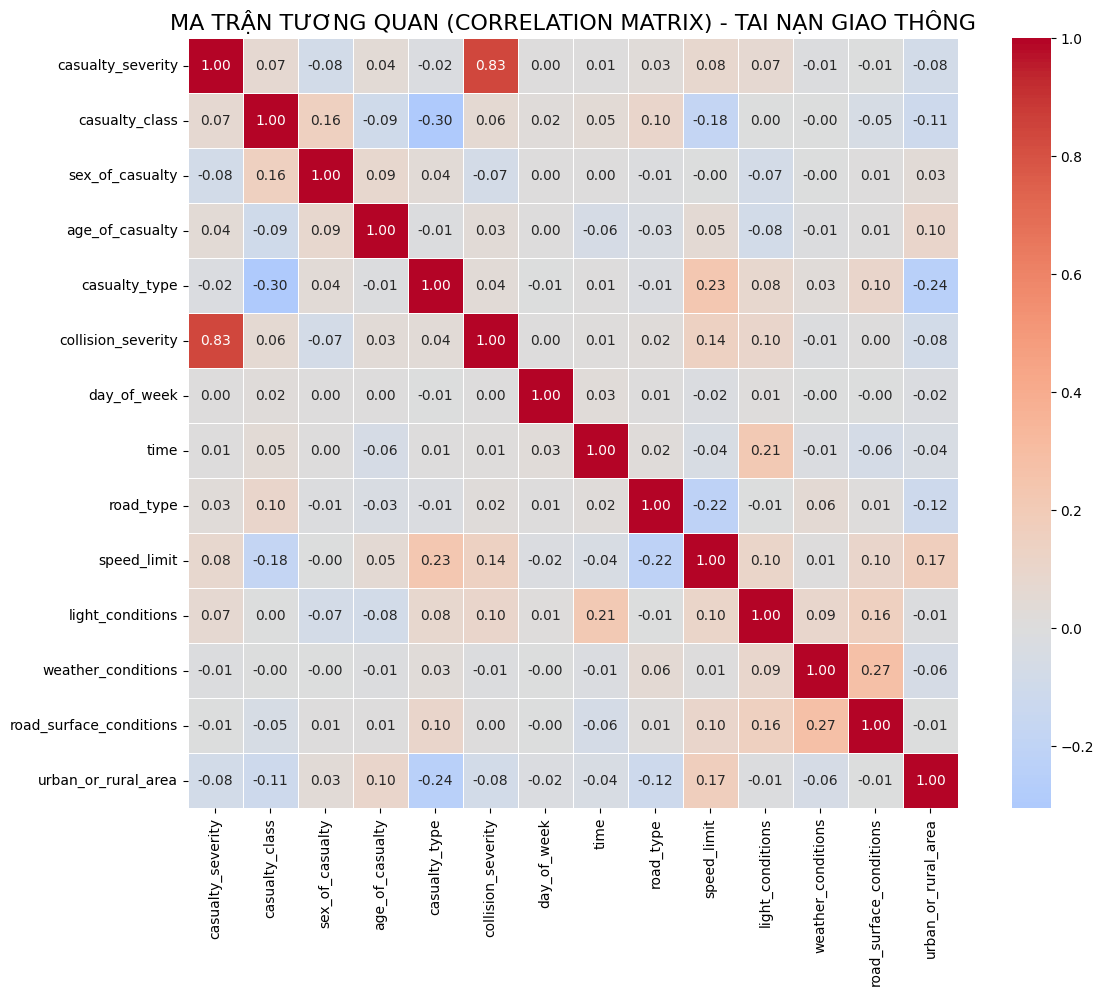

In [14]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. BƯỚC LỌC: Chọn các cột dạng số, loại bỏ cột String (collision_index) và Date (date)
cot_can_tinh = [
    "casualty_severity", # Đưa biến mục tiêu lên đầu để dễ nhìn
    "casualty_class", "sex_of_casualty", "age_of_casualty", 
    "casualty_type", "collision_severity", "day_of_week", 
    "time", "road_type", "speed_limit", "light_conditions", 
    "weather_conditions", "road_surface_conditions", "urban_or_rural_area"
]

# Xóa tạm các dòng có giá trị Null (Missing values) để phép tính không bị lỗi
df_so = df_data.select(cot_can_tinh).dropna()

df_so = df_so \
    .withColumn("casualty_severity",
        F.when(F.col("casualty_severity") == 1, 3)
         .when(F.col("casualty_severity") == 3, 1)
         .otherwise(F.col("casualty_severity"))
    ) \
    .withColumn("collision_severity",
        F.when(F.col("collision_severity") == 1, 3)
         .when(F.col("collision_severity") == 3, 1)
         .otherwise(F.col("collision_severity"))
    )

# 2. BƯỚC GOM: Đóng gói các cột thành một Vector (Yêu cầu bắt buộc của Spark MLlib)
assembler = VectorAssembler(inputCols=cot_can_tinh, outputCol="features")
df_vector = assembler.transform(df_so).select("features")

# 3. BƯỚC TÍNH TOÁN: Tính Ma trận tương quan Pearson
print("Đang huy động Spark tính toán ma trận (vui lòng đợi vài chục giây)...")
ma_tran_pyspark = Correlation.corr(df_vector, "features").head()

# Lấy mảng dữ liệu (mảng 2 chiều Numpy) từ kết quả của Spark
mang_tuong_quan = ma_tran_pyspark[0].toArray()

# 4. BƯỚC TRỰC QUAN HÓA: Đưa về Pandas và vẽ biểu đồ màu
df_pandas_corr = pd.DataFrame(mang_tuong_quan, index=cot_can_tinh, columns=cot_can_tinh)

plt.figure(figsize=(14, 10))
# Vẽ Heatmap: annot=True để hiện số, cmap="coolwarm" để tô màu xanh (âm) - đỏ (dương)
sns.heatmap(df_pandas_corr, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=.5)

plt.title("MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX) - TAI NẠN GIAO THÔNG", fontsize=16)
plt.show()

In [26]:
removed_cols = ['casualty_severity', 'sex_of_casualty', 'collision_severity', 'collision_index', 'date']
df_data = df_data.drop(*removed_cols)
df_data.printSchema()

root
 |-- casualty_class: integer (nullable = true)
 |-- age_of_casualty: integer (nullable = true)
 |-- casualty_type: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- time: integer (nullable = true)
 |-- road_type: integer (nullable = true)
 |-- speed_limit: integer (nullable = true)
 |-- light_conditions: integer (nullable = true)
 |-- weather_conditions: integer (nullable = true)
 |-- road_surface_conditions: integer (nullable = true)
 |-- urban_or_rural_area: integer (nullable = true)



In [27]:
cols = df_data.columns

In [28]:
assembler = VectorAssembler(inputCols=cols, outputCol="features", handleInvalid="keep")
df_vector = assembler.transform(df_data).select("features")
df_vector.show(5, truncate=False)

+---------------------------------------------------+
|features                                           |
+---------------------------------------------------+
|[1.0,24.0,109.0,2.0,3.0,9.0,30.0,4.0,8.0,3.0,-1.0] |
|[2.0,38.0,109.0,2.0,3.0,9.0,30.0,4.0,8.0,3.0,-1.0] |
|[2.0,30.0,109.0,2.0,12.0,9.0,30.0,1.0,8.0,3.0,-1.0]|
|[1.0,30.0,109.0,2.0,12.0,9.0,30.0,1.0,8.0,3.0,-1.0]|
|[1.0,38.0,109.0,2.0,12.0,3.0,70.0,1.0,8.0,3.0,-1.0]|
+---------------------------------------------------+
only showing top 5 rows
